**Students:** Thiago Almeida, Fatima Zahra
**Section:** A
**Date:** May 3, 2026
**Responsibilities:** Thiago Almeida: Q1 cleaning, Q3 monthly trend, written summaries. Fatima Zahra: Q2 ZIP code chart, Q4 cuisine table, chart formatting. Both: presentation.

# CAP3321C Final Project: Miami-Dade Restaurant Inspections

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Q1. Cleaning

In [2]:
df = pd.read_csv('mdc_restaurant_inspections_2025.csv')
print(df.shape)

(5018, 8)


In [3]:
df.isna().sum()

inspection_id     0
restaurant_name   0
zip_code          0
inspection_date   0
cuisine          9
score            44
violations        0
result            0
dtype: int64

`score` is what the whole project measures, so 44 inspections without a score cannot be imputed honestly. We drop them. Missing `cuisine` values were kept and labeled 'Unknown' so we do not lose inspections for Q2 and Q3.

In [4]:
df = df.dropna(subset=['score'])
df['cuisine'] = df['cuisine'].fillna('Unknown')
print(len(df))

4974


In [5]:
df['inspection_date'] = pd.to_datetime(df['inspection_date'])
df['score'] = pd.to_numeric(df['score'])
df['violations'] = pd.to_numeric(df['violations'])
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5)
print(df.dtypes)

inspection_id                int64
restaurant_name              object
zip_code                     object
inspection_date      datetime64[ns]
cuisine                      object
score                       float64
violations                    int64
result                       object


ZIP codes were stored as numbers, which drops leading zeros and breaks grouping, so we did convert them to 5-character strings. Dates became real dates so Q3 can group by month.

In [6]:
df = df.drop_duplicates(subset='inspection_id')
print(len(df))

4954


After removing 20 duplicate inspection ids, **4,954** inspections remain.

## Q2. Fail rate by ZIP code

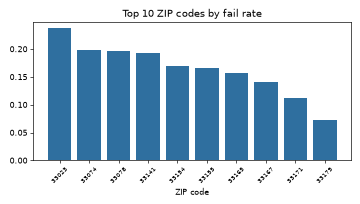

In [7]:
# share of inspections with result == 'Fail', per ZIP
fail_rate = df.assign(fail=df['result'] == 'Fail').groupby('zip_code')['fail'].mean()
top10 = fail_rate.sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.show()

ZIP code 33023 has highest fail rate (23.7%). The other ZIP codes are lower.

## Q3. Scores over time

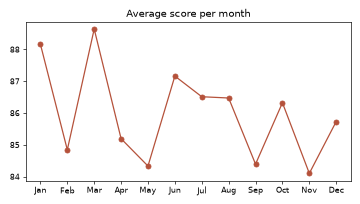

In [8]:
monthly = df.groupby(df['inspection_date'].dt.month)['score'].mean()
monthly.plot(marker='o')
plt.show()

The average score is highest in Mar and lowest in Nov.

## Q4. Violations by cuisine

In [9]:
per = df.groupby('cuisine')['violations'].mean().sort_values(ascending=False)
per.head(4)

cuisine   violations_per_inspection
Cuban     4.55
Peruvian  3.52
Haitian   3.2
Steakhouse1.92

Cuban has most violations per inspection (4.55), and Steakhouse fewest (1.92).